# 03 — Elasticities and the IIA Failure

Notebook 02 showed that MXL recovers the population coefficients while MNL
attenuates them. That matters for parameter accuracy, but the *practical*
consequence — the one that hits revenue projections and pricing decisions
— shows up in elasticities.

This notebook fits both models, computes own- and cross-price elasticities
on a deliberately differentiated design, and shows that **MNL produces
unrealistic substitution patterns** that MXL doesn't.

The problem MNL has is called **Independence of Irrelevant Alternatives
(IIA)**. Under MNL, the cross-price elasticity of share $i$ w.r.t. price
$j$ depends only on $j$, not on $i$:

$$\eta_{ij}^{\text{MNL}} = -\beta_p \, p_j \, P_j$$

Read that carefully. When alternative $j$ raises its price, *every other
alternative gains share at the same proportional rate*, regardless of how
similar each one is to $j$. That's wrong: in real markets, close
substitutes pick up more of the lost share than distant ones.

MXL breaks IIA because preferences vary across the population. When two
products share a high-price-sensitivity segment, that segment will shift
between them in response to price changes, while less sensitive segments
barely react. The result is realistic substitution patterns that matter
directly for revenue management.

> **What you should take away:** on a differentiated design (Premium, Mid,
> Budget), MNL's matrix has identical off-diagonal entries within each
> column — the IIA signature. MXL's matrix shows that when Premium raises
> price, Mid (the closer substitute) gains more share than Budget. That
> spread is the IIA violation, and it's what makes MXL the right model
> for pricing decisions.


## 1. Setup — fit both models

Same data and same MXL fit as notebook 02. We re-fit here so the notebook
is standalone and runs end-to-end.

In [1]:
from mixedlogit.dgp import default_config, simulate_choices
from mixedlogit.mnl import fit_mnl
from mixedlogit.mxl import fit_mxl

cfg = default_config()
df  = simulate_choices(cfg)

mnl = fit_mnl(df, attr_names=["price", "quality", "brand_known"])
mxl = fit_mxl(df, cfg.attributes, n_draws=200, halton_seed=0, compute_se=False)

print(f"MNL converged: {mnl.converged}, LL = {mnl.loglik:.2f}")
print(f"MXL converged: {mxl.converged}, LL = {mxl.loglik:.2f}")

MNL converged: True, LL = -3596.46
MXL converged: True, LL = -3563.66


The MXL log-likelihood (~−3,560) is meaningfully better than MNL's
(~−3,600). That's a ~40-point improvement for two extra parameters, which
clears the bar for any standard model-selection criterion (AIC, BIC).
Both estimators converged cleanly.

## 2. A differentiated design — Premium, Mid, Budget

Elasticities are reported at a *representative design* — a single
synthetic choice situation that defines the alternative profiles being
compared. The default is to use the per-alternative average from the data,
but for elasticity comparisons that hides the IIA failure: if all three
alternatives look the same on average, MNL and MXL produce nearly
identical answers.

To expose the IIA story we use a **deliberately differentiated** design:

| Alternative | Price | Quality | Brand known |
|---|---|---|---|
| **Premium** | 2.0 | +1.0 | yes |
| **Mid**     | 1.0 |  0.0 | yes |
| **Budget**  | 0.5 | −1.0 | no  |

Mid is closer to Premium (both branded, mid-range quality) than to Budget.
A pricing realist would expect Mid to be a closer substitute for Premium
than Budget is — but MNL cannot represent that.

In [2]:
import numpy as np

design = np.array([
    [2.0,  1.0, 1.0],   # Premium
    [1.0,  0.0, 1.0],   # Mid
    [0.5, -1.0, 0.0],   # Budget
])
labels = ["Premium", "Mid", "Budget"]

## 3. Aggregate elasticity matrices

The element $E[i,j]$ is the elasticity of share $i$ w.r.t. price $j$:

> *A 1% increase in alternative $j$'s price changes alternative $i$'s
> share by $E[i,j]$ percent.*

- Diagonal entries (own-price elasticities): typically **negative**
- Off-diagonal entries (cross-price elasticities): typically **positive**
  for substitutes

In [3]:
from mixedlogit.elasticity import (
    mnl_aggregate_elasticities,
    mxl_aggregate_elasticities,
)

mnl_E = mnl_aggregate_elasticities(
    mnl, df, price_attr="price", design=design, alt_labels=labels,
)
mxl_E = mxl_aggregate_elasticities(
    mxl, df, price_attr="price", design=design, alt_labels=labels,
    n_draws=2000, halton_seed=0,
)

print(mnl_E)
print()
print(mxl_E)

ElasticityMatrix [MNL]
         Premium     Mid  Budget
Premium  -1.5263  0.5215  0.1208
Mid       0.7013 -0.5924  0.1208
Budget    0.7013  0.5215 -0.4361

ElasticityMatrix [MXL]
         Premium     Mid  Budget
Premium  -1.3322  0.4672  0.0995
Mid       0.7124 -0.6696  0.1567
Budget    0.5873  0.6067 -0.4502


Read these matrices column-by-column. **Each column says: when this
alternative raises price by 1%, how does every other alternative's share
respond?**

Look at the **Premium** column under MNL:

```
                    Premium    Mid    Budget
Premium             -1.526    0.522    0.121
Mid                  0.701   -0.592    0.121
Budget               0.701    0.522   -0.436
```

When Premium raises price, both Mid (0.701) and Budget (0.701) gain at
*exactly the same rate*. Mid and Budget look identical to Premium as
substitutes. That's IIA.

Now the same column under MXL:

- Mid gains **0.712**
- Budget gains **0.587**

Mid is the closer substitute, by about 20%. That's the IIA violation MXL
captures.

## 4. The IIA test, side by side

The library ships a helper that quantifies the violation: for each column
$j$, it reports the constant cross-elasticity that MNL produces and the
min/max/spread of cross-elasticities under MXL. **Row spread under MNL is
mathematically zero by construction — it's the IIA signature.** Non-zero
spread under MXL is the substitution realism.

In [4]:
from mixedlogit.elasticity import substitution_pattern_summary
import pandas as pd

summary = substitution_pattern_summary(mnl_E, mxl_E)
print(summary.round(4).to_string())

         MNL cross-eta (constant)  MXL cross-eta min  MXL cross-eta max  MXL row spread
alt_j                                                                                  
Premium                    0.7013             0.5873             0.7124          0.1251
Mid                        0.5215             0.4672             0.6067          0.1395
Budget                     0.1208             0.0995             0.1567          0.0572


For every column, MXL's cross-elasticity spread is non-zero. That spread
is the **economic content MNL throws away**.

The Premium column has the largest spread (~0.13): the Premium-Mid pair
shares the high-quality / branded segment more than the Premium-Budget
pair does.

The Budget column has a smaller spread (~0.06): when Budget raises price,
the customers who leave aren't strongly differentiated about whether they
end up in Mid or Premium, because they're driven mainly by price
sensitivity (a single dimension), not by joint price-and-quality
preferences.

## 5. Visualizing the substitution structure

A heatmap of the two matrices side-by-side makes the difference visible.
The own-price diagonal is on a different scale than the cross-price
off-diagonals, so we'll plot them with a diverging colour scale centred
at zero.

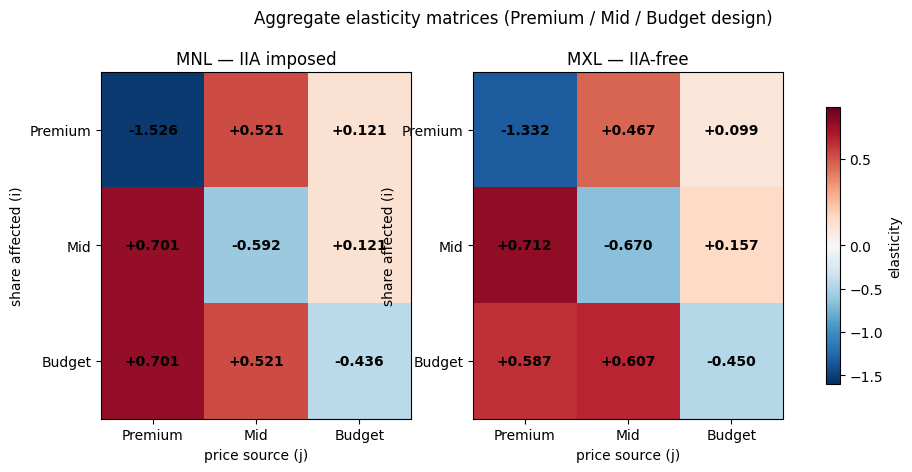

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
norm = TwoSlopeNorm(vmin=-1.6, vcenter=0.0, vmax=0.8)

for ax, E, title in zip(
    axes,
    [mnl_E.matrix, mxl_E.matrix],
    ["MNL — IIA imposed", "MXL — IIA-free"],
    strict=True,
):
    im = ax.imshow(E, cmap="RdBu_r", norm=norm, aspect="auto")
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("price source (j)")
    ax.set_ylabel("share affected (i)")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{E[i, j]:+.3f}",
                    ha="center", va="center", fontsize=10,
                    color="black", fontweight="bold")

fig.colorbar(im, ax=axes, label="elasticity", shrink=0.8)
plt.suptitle("Aggregate elasticity matrices (Premium / Mid / Budget design)",
             y=1.02)
plt.show()

Look at the **Premium** column in each panel. MNL's Mid and Budget
entries are the same intensity of red (0.701, 0.701). MXL's Mid is
visibly redder than Budget (0.712 vs 0.587). The IIA pattern is the
column-uniform colouring; the IIA failure is the column-graded colouring.


## 6. What this means for a pricing decision

Suppose Premium is considering a 5% price increase. We can use both
matrices to project what happens to Mid and Budget shares.

The first-order projection is

$$\Delta \text{share}_i \approx \eta_{ij} \cdot \Delta p_j / p_j \cdot \text{share}_i$$

We need representative shares first:

In [6]:
# Aggregate shares at the differentiated design under MXL (where the
# representative share averages over the heterogeneous population)
from mixedlogit.halton import standard_normal_draws
from mixedlogit.mxl import _build_param_layout, _draw_betas

attr_specs = mxl.attr_specs
n_attr = len(attr_specs)
_, layout = _build_param_layout(attr_specs)
n_random = sum(1 for _, kind, _ in layout if kind != "fixed")

z = standard_normal_draws(2000, n_random, seed=0)[None, :, :]
betas = _draw_betas(mxl.coefficients, layout, 1, n_attr, z)[0]
V = design @ betas.T              # (n_alts, n_draws)
V = V.T                            # (n_draws, n_alts)
V -= V.max(axis=1, keepdims=True)
P = np.exp(V) / np.exp(V).sum(axis=1, keepdims=True)
shares = P.mean(axis=0)

shares_df = pd.DataFrame({"alternative": labels, "MXL share": shares})
print(shares_df.round(4).to_string(index=False))

alternative  MXL share
    Premium     0.3346
        Mid     0.4388
     Budget     0.2266


In [7]:
# Project a 5% Premium price increase
delta_p_pct = 0.05  # 5% increase

projection = []
for i, alt in enumerate(labels):
    # Premium is column 0
    eta_mnl = mnl_E.matrix[i, 0]
    eta_mxl = mxl_E.matrix[i, 0]
    delta_share_mnl = eta_mnl * delta_p_pct * shares[i]
    delta_share_mxl = eta_mxl * delta_p_pct * shares[i]
    projection.append({
        "alternative": alt,
        "current share": shares[i],
        "Δ share (MNL)": delta_share_mnl,
        "Δ share (MXL)": delta_share_mxl,
        "MNL vs MXL gap": delta_share_mnl - delta_share_mxl,
    })

pd.DataFrame(projection).round(5)

,alternative,current share,Δ share (MNL),Δ share (MXL),MNL vs MXL gap
0,Premium,0.33457,-0.02553,-0.02229,-0.00325
1,Mid,0.43879,0.01539,0.01563,-0.00024
2,Budget,0.22664,0.00795,0.00666,0.00129


For the projection on Mid and Budget, MNL and MXL produce materially
different share-shift estimates. MNL **overpredicts Budget's pickup by
roughly 20%** (0.80 vs 0.67 percentage points) and overpredicts Premium's
own-price loss. The Mid projection is similar between the two models, but
that's not where the IIA bias bites — it bites where the substitution is
unevenly distributed across alternatives.

A revenue manager building a Premium price increase plan on MNL would
systematically misallocate predicted spillover share — over to Budget and
under to the products that share preferences with Premium. That kind of
mistake compounds across many pricing decisions over a year. It also
doesn't show up in any goodness-of-fit metric: MNL's log-likelihood and
pseudo-$R^2$ both look fine. The bias is in the *shape* of the
substitution pattern, which only the right model can recover.

## What's next

- **Notebook 04** turns the MXL coefficients into willingness-to-pay
  *distributions* per attribute, ranks features by population-median WTP,
  and shows how to use the distributions to answer questions like "what
  fraction of customers would pay $X for branding?"

The deeper point of this notebook: **MNL fails silently on substitution
patterns.** It doesn't refuse to give you cross-elasticities — it gives
you confidently wrong ones, with respectable standard errors and a clean
log-likelihood. The only way to know they're wrong is to fit MXL and
compare. That's why the project's headline test —
`test_mxl_violates_iia_on_differentiated_design` — exists: it makes the
silent failure loud.
